# Main Notebook
Este notebook `main.ipynb` é o ponto de partida para o processamento de dados do TCC.

## Visualizando o documento


In [5]:
import pandas as pd

df = pd.read_csv('base_RMS_final.csv')
df.head()

,DATA,LOTE,PRACA,SENTIDO,TIPO_CABINE,TIPO_PASSAGEM,TP_PAGAMENTO,LEVE-EIXOS 2,MOTO-EIXOS 2,PESADO-EIXOS 2,...,PESADO-EIXOS 43,PESADO-EIXOS 44,PESADO-EIXOS 45,PESADO-EIXOS 46,PESADO-EIXOS 47,PESADO-EIXOS 48,PESADO-EIXOS 51,arquivo_origem,PONTO_ID,CIDADE_NOME
0,2026-01-01,L13-COLINAS,BOITUVA,LESTE,AVI,VALIDAS,DINHEIRO,4,0,0,...,0,0,0,0,0,0,0,VOLUME_PEDAGIADO-L13-DIARIO-2026.csv,BOITUVA,ITU
1,2026-01-01,L13-COLINAS,BOITUVA,OESTE,MANUAL,VALIDAS,DINHEIRO,1170,0,3,...,0,0,0,0,0,0,0,VOLUME_PEDAGIADO-L13-DIARIO-2026.csv,BOITUVA,ITU
2,2026-01-01,L13-COLINAS,BOITUVA,LESTE,MANUAL,VALIDAS,DINHEIRO,1433,0,3,...,0,0,0,0,0,0,0,VOLUME_PEDAGIADO-L13-DIARIO-2026.csv,BOITUVA,ITU
3,2026-01-01,L13-COLINAS,BOITUVA,OESTE,AVI,VALIDAS,DINHEIRO,4,0,0,...,0,0,0,0,0,0,0,VOLUME_PEDAGIADO-L13-DIARIO-2026.csv,BOITUVA,ITU
4,2026-01-01,L13-COLINAS,BOITUVA,OESTE,MANUAL,ISENTAS,NÃO SE APLICA/ISENTO/EVASÃO,15,0,7,...,0,0,0,0,0,0,0,VOLUME_PEDAGIADO-L13-DIARIO-2026.csv,BOITUVA,ITU


## EDA

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_eixos = [col for col in df.columns if 'EIXOS' in col]
df['VOLUME_TOTAL'] = df[colunas_eixos].sum(axis=1)

# Converter a DATA para o formato datetime (fundamental para séries temporais)
df['DATA'] = pd.to_datetime(df['DATA'])

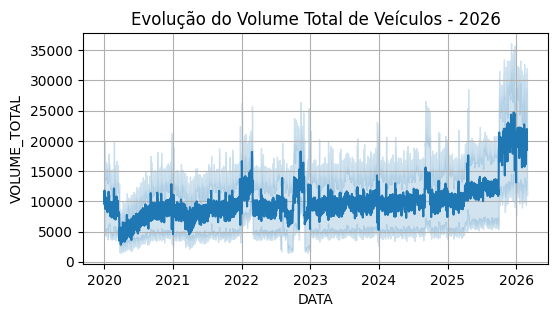

In [23]:
plt.figure(figsize=(6, 3))
df_diario = df.groupby(['DATA', 'PRACA'])['VOLUME_TOTAL'].sum().reset_index()
sns.lineplot(data=df_diario, x='DATA', y='VOLUME_TOTAL')
plt.title('Evolução do Volume Total de Veículos - 2026')
plt.grid(True)
plt.show()

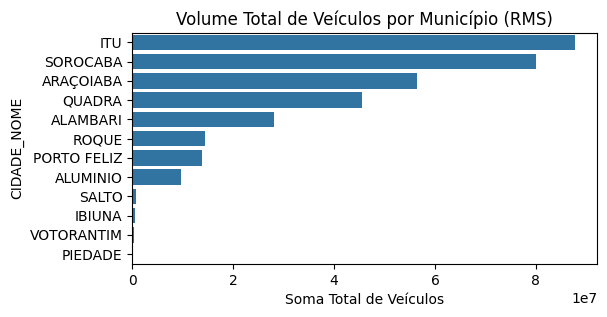

In [10]:
plt.figure(figsize=(6, 3))
df_total = df.groupby('CIDADE_NOME')['VOLUME_TOTAL'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=df_total, x='VOLUME_TOTAL', y='CIDADE_NOME')
plt.title('Volume Total de Veículos por Município (RMS)')
plt.xlabel('Soma Total de Veículos')
plt.show()

## Investigação do crescimento 25-26

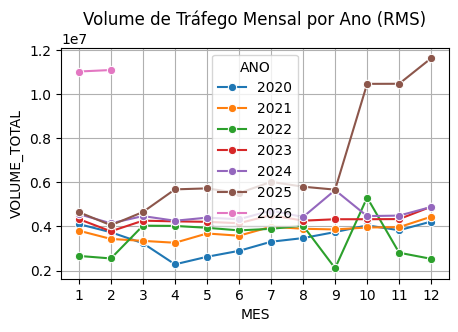

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que a coluna DATA é do tipo datetime
df_diario['DATA'] = pd.to_datetime(df_diario['DATA'])
df_total = df_diario.copy()

# Extrai o ano e o mês
df_total['ANO'] = df_total['DATA'].dt.year
df_total['MES'] = df_total['DATA'].dt.month

# Agrupa por Ano e Mês
df_mensal = df_total.groupby(['ANO', 'MES'])['VOLUME_TOTAL'].sum().reset_index()

# Plota um gráfico de linhas separando os anos
plt.figure(figsize=(5, 3))
sns.lineplot(data=df_mensal, x='MES', y='VOLUME_TOTAL', hue='ANO', palette='tab10', marker='o')
plt.title('Volume de Tráfego Mensal por Ano (RMS)')
plt.xticks(range(1, 13)) # Força o eixo X a mostrar de 1 a 12 (meses)
plt.grid(True)
plt.show()

In [25]:
df_total['DATA'] = pd.to_datetime(df_total['DATA'])

# 2. Cria a coluna 'ANO' extraindo apenas o ano da data
df_total['ANO'] = df_total['DATA'].dt.year

# 3. Agora sim, o seu filtro original vai funcionar perfeitamente!
df_2024 = df_total[df_total['ANO'] == 2024]
df_2025 = df_total[df_total['ANO'] == 2025]

# Cria conjuntos (sets) com os nomes únicos das praças em cada ano
pracas_2024 = set(df_2024['PRACA'].unique())
pracas_2025 = set(df_2025['PRACA'].unique())

# A mágica da Teoria dos Conjuntos para achar as diferenças
pracas_novas = pracas_2025 - pracas_2024
pracas_removidas = pracas_2024 - pracas_2025

print("--- INVESTIGAÇÃO DE PONTOS DE COBRANÇA ---")

if len(pracas_novas) > 0:
    print(f"🚨 HIPÓTESE CONFIRMADA! Praças que surgiram em 2025: {pracas_novas}")
else:
    print("Nenhuma praça nova foi adicionada em 2025. O crescimento é orgânico.")

if len(pracas_removidas) > 0:
    print(f"⚠️ Praças que foram desativadas em 2025: {pracas_removidas}")

--- INVESTIGAÇÃO DE PONTOS DE COBRANÇA ---
🚨 HIPÓTESE CONFIRMADA! Praças que surgiram em 2025: {'PÓRTICO 06 - SÃO ROQUE', 'PÓRTICO 07 - SÃO ROQUE', 'ARAÇOIABA LESTE', 'PÓRTICO 12 - ARAÇOIABA', 'ITU', 'PÓRTICO 09 - SOROCABA', 'PÓRTICO 11 - SOROCABA', 'ALUMINIO', 'PÓRTICO 10 - SOROCABA'}


In [26]:
# Pegar apenas as praças que existiam TANTO em 2024 QUANTO em 2025 (Interseção)
pracas_comuns = pracas_2024.intersection(pracas_2025)

# Filtrar o dataset final para conter apenas o histórico das praças consistentes
df_ml = df_total[df_total['PRACA'].isin(pracas_comuns)]

print(f"Dataset reduzido para {len(pracas_comuns)} praças históricas consistentes.")

Dataset reduzido para 15 praças históricas consistentes.



Gerando Visão Comparativa por Praça de Pedágio...

--- CRESCIMENTO REAL POR PRAÇA (2024 vs 2025) ---
ANO                       2020       2021       2022        2023        2024  \
PRACA                                                                          
PÓRTICO ITU - 1        21000.0    24701.0    26743.0     28730.0     22189.0   
PÓRTICO SALTO - 2      47923.0    43919.0    48846.0     57153.0     54668.0   
SOROCABA             7882408.0  8847921.0  7883047.0  10521720.0  11119899.0   
QUADRA               6378565.0  6659816.0  7154612.0   7742767.0   7952750.0   
ALAMBARI             3853420.0  4234093.0  4482436.0   4786982.0   4937721.0   
PÓRTICO ITU - 2        17432.0    19034.0    22067.0     29298.0     34365.0   
PORTO FELIZ          2005477.0  2100250.0  1871642.0   2274531.0   2588903.0   
PÓRTICO SALTO - 3      47978.0    29625.0    31720.0     51838.0     72637.0   
BOITUVA              8840347.0  9413714.0  8432465.0  10824136.0  12072613.0   
BLOQUEIO DE BOITUV

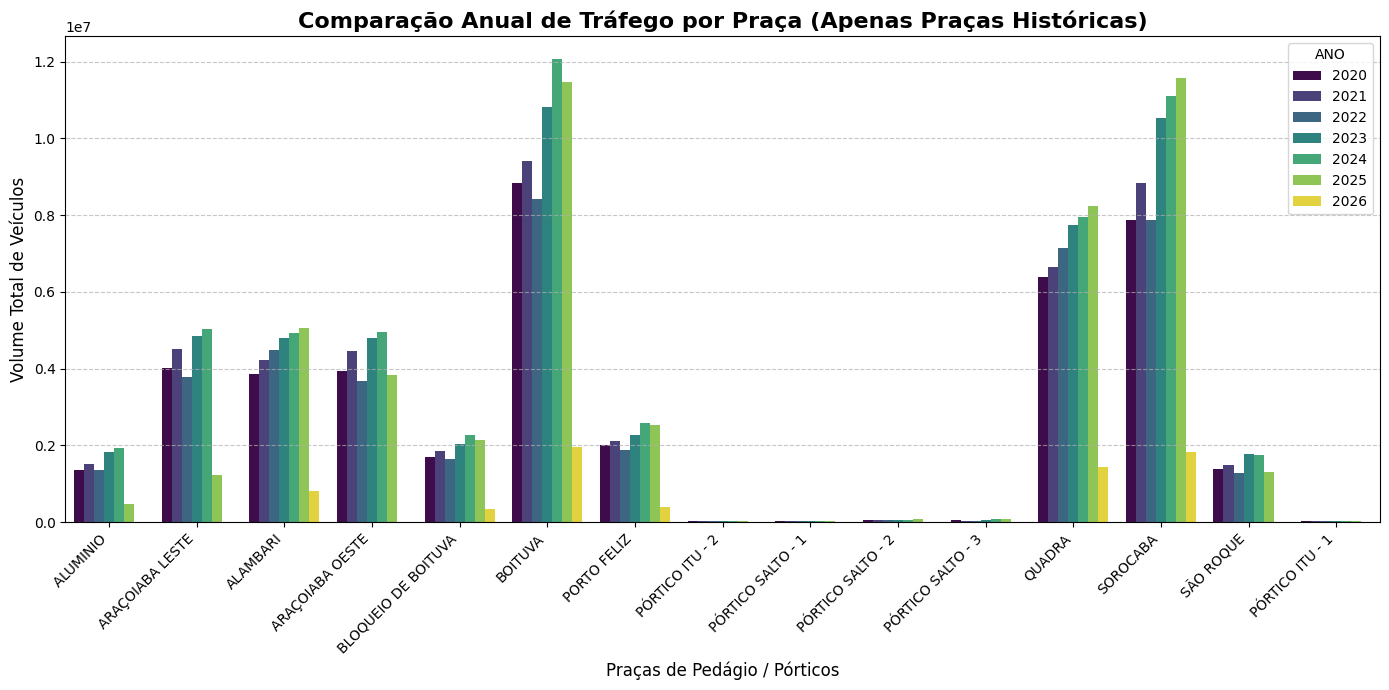

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==========================================
# VISÃO 1: TABELA COMPARATIVA (Pivot Table)
# ==========================================
print("\nGerando Visão Comparativa por Praça de Pedágio...")

# Cria uma tabela cruzando as Praças e os Anos
tabela_comparativa = df_ml.pivot_table(
    index='PRACA',         # <--- MUDANÇA AQUI: Usando PRACA ao invés de CIDADE_NOME
    columns='ANO', 
    values='VOLUME_TOTAL', 
    aggfunc='sum'
).fillna(0)

# Calcula o crescimento real em porcentagem
if 2024 in tabela_comparativa.columns and 2025 in tabela_comparativa.columns:
    tabela_comparativa['Variação (%)'] = ((tabela_comparativa[2025] - tabela_comparativa[2024]) / tabela_comparativa[2024]) * 100

print("\n--- CRESCIMENTO REAL POR PRAÇA (2024 vs 2025) ---")
print(tabela_comparativa.round(2).sort_values(by='Variação (%)', ascending=False))


# ==========================================
# VISÃO 2: GRÁFICO DE BARRAS AGRUPADAS
# ==========================================
plt.figure(figsize=(14, 7))

# Cria as barras comparativas (2024 do lado de 2025)
sns.barplot(
    data=df_ml, 
    x='PRACA',             # <--- MUDANÇA AQUI também
    y='VOLUME_TOTAL', 
    hue='ANO', 
    estimator=sum, 
    errorbar=None, 
    palette='viridis' 
)

plt.title('Comparação Anual de Tráfego por Praça (Apenas Praças Históricas)', fontsize=16, fontweight='bold')
plt.xlabel('Praças de Pedágio / Pórticos', fontsize=12)
plt.ylabel('Volume Total de Veículos', fontsize=12)

# Gira os nomes das praças para não ficarem encavalados
plt.xticks(rotation=45, ha='right') 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibe o gráfico
plt.show()